# PHÂN TÍCH VÀ DỰ BÁO GIÁ NHÀ TẠI HÀ NỘI
## BẰNG MÔ HÌNH HỒI QUY TUYẾN TÍNH ĐA BIẾN

**Dữ liệu:** `HN_Houseprice.csv` — dữ liệu tin rao bán bất động sản thô, thu thập từ các trang mua bán nhà đất tại Hà Nội.

**Cấu trúc notebook:**
1. Đọc và khảo sát dữ liệu thô
2. Tiền xử lý dữ liệu (Data Preprocessing)
3. Phân tích mô tả (EDA)
4. Xây dựng mô hình hồi quy tuyến tính đa biến
5. Phân tích kết quả dự báo
6. Phân tích sai số (Error Analysis)
7. Kết luận


## 0. Import thư viện

In [380]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42


## 1. Đọc và khảo sát dữ liệu thô

Trước khi xử lý, ta cần hiểu cấu trúc, kiểu dữ liệu và các vấn đề "bẩn" (dirty data) trong file gốc.

In [381]:
df_raw = pd.read_csv('HN_Houseprice.csv')
print("Kích thước dữ liệu thô:", df_raw.shape)
df_raw.head()


Kích thước dữ liệu thô: (13535, 15)


,Title,Address,District,PostingDate,PostType,Price,Area,Direction,Bedrooms,Bathrooms,Floors,Width_meters,Legal,Interior,Entrancewidth
0,Top 10 căn đầu tư tốt nhất tại Vinhome Cổ Loa ...,"Dự án Vinhomes Cổ Loa, Đường Cổ Loa, Xã Đông H...",Đông Anh,16/12/2024,"Nhà biệt thự, liền kề tại Vinhomes Cổ Loa",15 tỷ,63 m²,0,0,0,5 tầng,0,0,0,0
1,Tổng kho hàng chuyển nhượng vị trí đẹp giá rẻ ...,"Dự án An Lạc Green Symphony, Đường Vành Đai 3....",Hoài Đức,16/12/2024,"Nhà biệt thự, liền kề tại An Lạc Green Symphony","21,5 tỷ",90 m²,Tây - Nam,0,0,4 tầng,5 m,* Pháp lý: Tất cả các căn đã ký Hợp đồng mua bán.,0,58 m
2,CĐT mở bán quỹ căn HOT cuối cùng đẹp nhất The ...,"The Diamond Residence, 25 Đường Lê Văn Lương, ...",Thanh Xuân,16/12/2024,Căn hộ chung cư tại The Diamond Residence,Thỏa thuận,107 m²,0,3 phòng,3 phòng,0,0,Hợp đồng mua bán,0,0
3,Bán biệt thự song lập 150m2 Vin Ocean Park Gia...,"Dự án Vinhomes Ocean Park Gia Lâm, Xã Dương Xá...",Gia Lâm,16/12/2024,"Nhà biệt thự, liền kề tại Vinhomes Ocean Park ...",26 tỷ,150 m²,0,0,0,0,0,Sổ đỏ.,0,0
4,Tạo ngay ra dòng tiền 360 triệu/năm với số vốn...,"Dự án Vinhomes Golden Avenue Móng Cái, Phường ...",Móng Cái,16/12/2024,"Nhà biệt thự, liền kề tại Vinhomes Golden Aven...",6 tỷ,90 m²,0,0,0,5 tầng,5 m,Sổ đỏ/ Sổ hồng,0,"17,5 m"


In [382]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 13535 entries, 0 to 13534
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Title          13535 non-null  str  
 1   Address        13535 non-null  str  
 2   District       13535 non-null  str  
 3   PostingDate    13535 non-null  str  
 4   PostType       13535 non-null  str  
 5   Price          13535 non-null  str  
 6   Area           13535 non-null  str  
 7   Direction      13535 non-null  str  
 8   Bedrooms       13535 non-null  str  
 9   Bathrooms      13535 non-null  str  
 10  Floors         13535 non-null  str  
 11  Width_meters   13535 non-null  str  
 12  Legal          13535 non-null  str  
 13  Interior       13535 non-null  str  
 14  Entrancewidth  13535 non-null  str  
dtypes: str(15)
memory usage: 1.5 MB


In [383]:
# Toàn bộ các cột đều đang là kiểu chuỗi (object), vì dữ liệu thô lưu kèm đơn vị
# (m², tỷ, triệu/m², phòng, tầng, m ...) và nhiều giá trị placeholder '0' cho ô trống.
for c in df_raw.columns:
    print(f"{c:15s} -> {df_raw[c].nunique()} giá trị duy nhất | ví dụ: {df_raw[c].unique()[:3]}")


Title           -> 10780 giá trị duy nhất | ví dụ: <StringArray>
['Top 10 căn đầu tư tốt nhất tại Vinhome Cổ Loa - mua trực tiếp CĐT chiết khấu 22.5% LH: 0818 008 ***',
                        'Tổng kho hàng chuyển nhượng vị trí đẹp giá rẻ - giá cho nhà đầu cơ/tiêu dùng',
        'CĐT mở bán quỹ căn HOT cuối cùng đẹp nhất The Diamond 25 Lê Văn Lương: 107m2 - 144m2 - 202m2']
Length: 3, dtype: str
Address         -> 3951 giá trị duy nhất | ví dụ: <StringArray>
[                 'Dự án Vinhomes Cổ Loa, Đường Cổ Loa, Xã Đông Hội, Đông Anh, Hà Nội',
      'Dự án An Lạc Green Symphony, Đường Vành Đai 3.5, Xã Vân Canh, Hoài Đức, Hà Nội',
 'The Diamond Residence, 25 Đường Lê Văn Lương, Phường Nhân Chính, Thanh Xuân, Hà Nội']
Length: 3, dtype: str
District        -> 40 giá trị duy nhất | ví dụ: <StringArray>
['Đông Anh', 'Hoài Đức', 'Thanh Xuân']
Length: 3, dtype: str
PostingDate     -> 35 giá trị duy nhất | ví dụ: <StringArray>
['16/12/2024', '12/12/2024', '11/12/2024']
Length: 3, dtype: str
P

## 2. Tiền xử lý dữ liệu (Data Preprocessing)

Dữ liệu thô có các vấn đề chính cần xử lý:

| Vấn đề | Cách xử lý |
|---|---|
| `Price` lẫn nhiều đơn vị: "tỷ", "triệu/m²", "triệu/tháng", "Thỏa thuận" | Quy đổi thống nhất về **tỷ VNĐ (giá bán toàn bộ BĐS)**; loại tin cho thuê và tin "thỏa thuận" (không có giá trị số) |
| `Area`, `Bedrooms`, `Bathrooms`, `Floors`, `Width_meters`, `Entrancewidth` là chuỗi kèm đơn vị, giá trị "0" = không có dữ liệu | Tách số, đổi `0` → `NaN` |
| `District` chứa vài tỉnh/thành ngoài Hà Nội (do đăng tin sai) | Lọc chỉ giữ 30 quận/huyện thuộc Hà Nội |
| `PostType` gộp loại hình BĐS + tên dự án | Tách lấy **loại hình bất động sản** (`PropertyType`) |
| `Legal`, `Interior`, `Direction` là văn bản tự do, rất nhiều biến thể | Gom nhóm thành các phạm trù (category) chính |
| Giá trị khuyết (missing) | Impute (điền) hợp lý theo loại hình BĐS, hoặc loại bỏ dòng nếu biến quá quan trọng mà thiếu |
| Giá trị ngoại lai (outlier) — VD phòng ngủ = 255 | Loại bỏ bằng phương pháp IQR + giới hạn hợp lý theo miền giá trị |


### 2.1. Loại bỏ tin đăng trùng lặp (Duplicate Removal)

Khảo sát dữ liệu thô cho thấy có rất nhiều bản ghi bị **trùng lặp** — cùng một bất động sản (cùng địa chỉ, quận/huyện, giá, diện tích, số phòng ngủ/tắm, số tầng, pháp lý, nội thất...) nhưng được đăng tin nhiều lần, chỉ khác tiêu đề (`Title`) hoặc ngày đăng (`PostingDate`). Đây là hiện tượng phổ biến trên các nền tảng rao vặt (người đăng tin "đẩy tin" định kỳ để tin không bị trôi xuống dưới). Nếu không loại bỏ, các bất động sản này sẽ bị đếm nhiều lần, làm sai lệch thống kê mô tả và khiến mô hình học lệch về phía các bất động sản được đăng lại nhiều lần.

Ta xác định một tin đăng là "trùng lặp" nếu **toàn bộ các trường đặc tả bất động sản** (địa chỉ, quận/huyện, giá, diện tích, hướng, số phòng ngủ, số phòng tắm, số tầng, chiều rộng, pháp lý, nội thất, chiều rộng lối vào, loại hình BĐS) giống hệt nhau — chỉ cho phép khác nhau ở `Title` và `PostingDate` (vốn thay đổi mỗi lần đẩy tin).

In [384]:
dup_identity_cols = ['Address','District','Price','Area','Direction','Bedrooms',
    'Bathrooms','Floors','Width_meters','Legal','Interior','Entrancewidth','PostType']

n_before = len(df_raw)
n_dup = df_raw.duplicated(subset=dup_identity_cols, keep='first').sum()
print(f"Số bản ghi thô ban đầu: {n_before}")
print(f"Số bản ghi trùng lặp (cùng vị trí & thông số, chỉ khác tiêu đề/ngày đăng): {n_dup} ({n_dup/n_before*100:.1f}%)")

df_raw = df_raw.drop_duplicates(subset=dup_identity_cols, keep='first').reset_index(drop=True)
print(f"Số bản ghi còn lại sau khi loại trùng lặp: {len(df_raw)}")


Số bản ghi thô ban đầu: 13535
Số bản ghi trùng lặp (cùng vị trí & thông số, chỉ khác tiêu đề/ngày đăng): 2774 (20.5%)
Số bản ghi còn lại sau khi loại trùng lặp: 10761


### 2.2. Chuẩn hoá cột diện tích (`Area`) và giá (`Price`)

In [385]:
def parse_num(x):
    """Chuyển chuỗi số kiểu Việt Nam (dấu phẩy thập phân) sang float."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip().replace(',', '.')
    try:
        return float(x)
    except ValueError:
        return np.nan

df = df_raw.copy()

# --- Diện tích ---
df['Area_m2'] = df['Area'].astype(str).str.replace(' m²', '', regex=False).apply(parse_num)

# --- Giá bán ---
def parse_price(row):
    p = str(row['Price']).strip()
    area = row['Area_m2']
    if 'tỷ' in p:
        return parse_num(p.replace('tỷ', '').strip())
    if 'triệu/m²' in p:
        # giá niêm yết theo m2 -> quy đổi ra tổng giá trị căn nhà
        gia_m2_trieu = parse_num(p.replace('triệu/m²', '').strip())
        if pd.isna(gia_m2_trieu) or pd.isna(area):
            return np.nan
        return gia_m2_trieu * area / 1000.0   # triệu -> tỷ
    if 'triệu/tháng' in p:
        return np.nan   # tin cho THUÊ, không phải giá BÁN -> loại khỏi bài toán
    if 'triệu' in p:
        so_trieu = parse_num(p.replace('triệu', '').strip())
        return so_trieu / 1000.0 if not pd.isna(so_trieu) else np.nan
    return np.nan   # 'Thỏa thuận', '0', 'nghìn' ... -> không xác định được giá trị số

df['Price_ty'] = df.apply(parse_price, axis=1)

print(f"Số dòng có giá bán xác định được (dạng số, đơn vị tỷ VNĐ): {df['Price_ty'].notna().sum()} / {len(df)}")


Số dòng có giá bán xác định được (dạng số, đơn vị tỷ VNĐ): 9422 / 10761


### 2.3. Chuẩn hoá số phòng ngủ, phòng tắm, số tầng

In [386]:
def parse_room(x):
    x = str(x).strip()
    if x in ('0', 'nan'):
        return np.nan
    return parse_num(x.replace('phòng', '').strip())

def parse_floor(x):
    x = str(x).strip()
    if x in ('0', 'nan'):
        return np.nan
    return parse_num(x.replace('tầng', '').strip())

df['Bedrooms_n']  = df['Bedrooms'].apply(parse_room)
df['Bathrooms_n'] = df['Bathrooms'].apply(parse_room)
df['Floors_n']    = df['Floors'].apply(parse_floor)

df[['Bedrooms_n','Bathrooms_n','Floors_n']].describe()


,Bedrooms_n,Bathrooms_n,Floors_n
count,7532.000000,6959.000000,5025.000000
mean,4.244025,3.871533,4.919403
std,6.206185,5.382244,1.721235
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,5.000000
75%,4.000000,4.000000,6.000000
max,255.000000,149.000000,27.000000


### 2.4. Trích xuất loại hình bất động sản, gom nhóm pháp lý & nội thất

Cột `PostType` có dạng `"<Loại hình BĐS> tại <Tên dự án>"`, ta tách lấy phần loại hình.
Cột `Legal` và `Interior` là văn bản mô tả tự do rất đa dạng → gom về vài nhóm chính để dùng làm biến phân loại (categorical) trong mô hình hồi quy.

In [387]:
df['PropertyType'] = df['PostType'].str.split(' tại ').str[0]

def cat_legal(x):
    x = str(x)
    if x == '0':
        return 'Chưa rõ'
    xl = x.lower()
    if 'sổ đỏ' in xl or 'sổ hồng' in xl or 'có sổ' in xl:
        return 'Sổ đỏ/Sổ hồng'
    if 'hợp đồng mua bán' in xl or 'hđmb' in xl:
        return 'HĐMB'
    if 'đang chờ sổ' in xl:
        return 'Đang chờ sổ'
    return 'Khác'

def cat_interior(x):
    x = str(x)
    if x == '0':
        return 'Chưa rõ'
    xl = x.lower()
    if 'không nội thất' in xl:
        return 'Không nội thất'
    if 'cao cấp' in xl or 'đầy đủ' in xl or 'full' in xl:
        return 'Đầy đủ/Cao cấp'
    if 'cơ bản' in xl or 'hoàn thiện' in xl:
        return 'Cơ bản'
    return 'Khác'

df['Legal_cat']     = df['Legal'].apply(cat_legal)
df['Interior_cat']  = df['Interior'].apply(cat_interior)
df['Direction_cat'] = df['Direction'].replace('0', 'Chưa rõ')

print(df['PropertyType'].value_counts())


PropertyType
Nhà riêng                        3682
Căn hộ chung cư                  3506
Bán đất                          1364
Nhà biệt thự, liền kề            1088
Nhà mặt phố                       839
Shophouse, nhà phố thương mại     135
Chung cư mini, căn hộ dịch vụ      63
Loại bất động sản khác             28
Kho, nhà xưởng                     23
Đất nền dự án                      21
Trang trại, khu nghỉ dưỡng         10
0                                   1
Condotel                            1
Name: count, dtype: int64


### 2.5. Lọc phạm vi phân tích

Đề tài giới hạn ở **giá nhà tại Hà Nội**, và mô hình hồi quy tuyến tính đa biến sẽ áp dụng cho các **loại hình bất động sản để ở** (nhà riêng, chung cư, biệt thự/liền kề, nhà mặt phố, shophouse...). Đất nền, kho xưởng, trang trại... có bản chất định giá khác hẳn nên được loại khỏi phạm vi.

In [388]:
hanoi_districts = ['Ba Đình','Hoàn Kiếm','Tây Hồ','Long Biên','Cầu Giấy','Đống Đa',
    'Hai Bà Trưng','Hoàng Mai','Thanh Xuân','Nam Từ Liêm','Bắc Từ Liêm','Hà Đông',
    'Sơn Tây','Ba Vì','Chương Mỹ','Đan Phượng','Đông Anh','Gia Lâm','Hoài Đức',
    'Mê Linh','Mỹ Đức','Phú Xuyên','Phúc Thọ','Quốc Oai','Sóc Sơn','Thạch Thất',
    'Thanh Oai','Thanh Trì','Thường Tín','Ứng Hòa']

residential_types = ['Nhà riêng','Căn hộ chung cư','Nhà biệt thự, liền kề','Nhà mặt phố',
    'Shophouse, nhà phố thương mại','Chung cư mini, căn hộ dịch vụ','Condotel']

before = len(df)
df = df[df['District'].isin(hanoi_districts)]
df = df[df['PropertyType'].isin(residential_types)]
df = df.dropna(subset=['Price_ty', 'Area_m2'])   # bắt buộc phải có giá và diện tích
print(f"Số dòng: {before} -> {len(df)} sau khi lọc phạm vi Hà Nội / loại hình để ở / có giá & diện tích")


Số dòng: 10761 -> 8233 sau khi lọc phạm vi Hà Nội / loại hình để ở / có giá & diện tích


### 2.5b. Gộp nhóm loại hình bất động sản hiếm gặp (Rare Category Grouping)

Sau bước lọc phạm vi, khảo sát lại `PropertyType` cho thấy loại hình **`Condotel` chỉ có đúng **1 quan sát** duy nhất trong toàn bộ dữ liệu (đây là đặc điểm thật của dữ liệu thu thập được, không phải lỗi parse/tiền xử lý — dòng dữ liệu này có đầy đủ giá, diện tích, số phòng hợp lý).

Về mặt thống kê, khi một hạng mục phân loại chỉ xuất hiện **đúng 1 lần** và được mã hoá one-hot thành biến giả (dummy) riêng, biến giả đó chỉ nhận giá trị 1 ở duy nhất dòng đó — buộc mô hình OLS phải khớp hoàn hảo quan sát này, khiến **đòn bẩy (leverage) của quan sát bằng đúng 1 (giá trị tối đa lý thuyết)**. Đây là hệ quả toán học tất yếu của "biến giả đơn nhất" (singleton dummy) chứ không phải sai sót ở bước làm sạch dữ liệu; tuy nhiên hệ số hồi quy ước lượng cho một hạng mục chỉ có 1 quan sát là hoàn toàn không đáng tin cậy (không có phương sai để ước lượng), nên cần gộp các loại hình quá hiếm (< 10 quan sát) vào nhóm gần nhất về bản chất trước khi đưa vào mô hình.


In [389]:
# Gộp các loại hình bất động sản có quá ít quan sát (< 10) vào nhóm gần nhất về bản chất,
# để tránh tạo biến giả (dummy) "đơn nhất" chỉ đại diện cho 1 quan sát duy nhất — nguyên nhân
# khiến quan sát đó có leverage tuyệt đối = 1 khi hồi quy OLS (xem giải thích ở mục 4.5).
RARE_THRESHOLD = 10
type_counts = df['PropertyType'].value_counts()
rare_types = type_counts[type_counts < RARE_THRESHOLD].index.tolist()
print("Số quan sát theo loại hình trước khi gộp:")
print(type_counts)
print(f"\nCác loại hình có < {RARE_THRESHOLD} quan sát (sẽ được gộp): {rare_types}")

# Condotel và các loại hình hiếm khác thuộc phân khúc "căn hộ dịch vụ quy mô nhỏ" -> gộp
# vào nhóm 'Chung cư mini, căn hộ dịch vụ' (gần nhất về bản chất sản phẩm và mức giá).
df['PropertyType'] = df['PropertyType'].replace(
    {t: 'Chung cư mini, căn hộ dịch vụ' for t in rare_types}
)

print("\nSố quan sát theo loại hình sau khi gộp:")
print(df['PropertyType'].value_counts())


Số quan sát theo loại hình trước khi gộp:
PropertyType
Nhà riêng                        3499
Căn hộ chung cư                  2928
Nhà biệt thự, liền kề             860
Nhà mặt phố                       785
Shophouse, nhà phố thương mại      99
Chung cư mini, căn hộ dịch vụ      61
Condotel                            1
Name: count, dtype: int64

Các loại hình có < 10 quan sát (sẽ được gộp): ['Condotel']

Số quan sát theo loại hình sau khi gộp:
PropertyType
Nhà riêng                        3499
Căn hộ chung cư                  2928
Nhà biệt thự, liền kề             860
Nhà mặt phố                       785
Shophouse, nhà phố thương mại      99
Chung cư mini, căn hộ dịch vụ      62
Name: count, dtype: int64


### 2.6. Xử lý giá trị khuyết (Missing Values)

- Với **chung cư/condotel** (loại hình vốn chỉ có 1 sàn căn hộ), số tầng của *toà nhà* thường không được người đăng điền → hợp lý để gán `Floors_n = 1` (đại diện cho 1 sàn căn hộ).
- Với các biến số còn thiếu (`Bedrooms_n`, `Bathrooms_n`, `Floors_n`), ta điền bằng **trung vị theo từng loại hình bất động sản** — vì số phòng/tầng phụ thuộc mạnh vào loại hình (biệt thự khác căn hộ).

In [390]:
apt_types = ['Căn hộ chung cư','Chung cư mini, căn hộ dịch vụ','Condotel']
df.loc[df['PropertyType'].isin(apt_types) & df['Floors_n'].isna(), 'Floors_n'] = 1

missing_before = df[['Bedrooms_n','Bathrooms_n','Floors_n']].isna().sum()

for col in ['Bedrooms_n','Bathrooms_n','Floors_n']:
    df[col] = df.groupby('PropertyType')[col].transform(lambda s: s.fillna(s.median()))
    df[col] = df[col].fillna(df[col].median())

print("Số giá trị khuyết trước khi điền:\n", missing_before)
print("\nSố giá trị khuyết sau khi điền:\n", df[['Bedrooms_n','Bathrooms_n','Floors_n']].isna().sum())


Số giá trị khuyết trước khi điền:
 Bedrooms_n     1539
Bathrooms_n    2052
Floors_n        610
dtype: int64

Số giá trị khuyết sau khi điền:
 Bedrooms_n     0
Bathrooms_n    0
Floors_n       0
dtype: int64


### 2.7. Xử lý giá trị ngoại lai (Outliers)

Sử dụng phương pháp **IQR (Interquartile Range)**: loại các quan sát nằm ngoài khoảng `[Q1 − k·IQR, Q3 + k·IQR]` với `k = 3` (ngưỡng rộng, chỉ loại các giá trị *thực sự* bất thường — ví dụ tin đăng nhầm phòng ngủ = 255), kết hợp thêm vài giới hạn hợp lý theo lẽ thường (diện tích ≤ 1000 m², số phòng ≤ 20).

In [391]:
def iqr_bounds(s, k=3.0):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

n0 = len(df)
for col in ['Price_ty','Area_m2','Bedrooms_n','Bathrooms_n','Floors_n']:
    lo, hi = iqr_bounds(df[col])
    lo = max(lo, 0)
    before = len(df)
    df = df[(df[col] >= lo) & (df[col] <= hi)]
    print(f"{col:12s}: loại {before-len(df):4d} dòng | ngưỡng hợp lệ ~ [{lo:.2f}, {hi:.2f}]")

# Giới hạn hợp lý bổ sung theo lẽ thường (bắt các trường hợp lọt IQR nhưng vẫn phi thực tế,
# ví dụ 1 căn "nhà mặt phố" khai 24 tầng - rõ ràng là lỗi nhập liệu)
df = df[(df['Area_m2'] <= 1000) & (df['Bedrooms_n'] <= 20) & (df['Bathrooms_n'] <= 20) & (df['Floors_n'] <= 20)]

# Ngưỡng giá tối thiểu hợp lý: một số bản ghi có Price_ty < 0.3 tỷ (dưới 300 triệu) cho cả căn nhà
# là lỗi nhập liệu ở nguồn dữ liệu gốc (ví dụ trường Price ghi nhầm đơn vị "triệu" thay vì "tỷ" -
# mâu thuẫn với giá nêu trong tiêu đề tin đăng). Các tin hợp lệ rẻ nhất thực tế (nhà ngõ nhỏ,
# chung cư mini) vẫn thường ở mức 0.5-1 tỷ trở lên, nên ngưỡng 0.3 tỷ là phù hợp và an toàn.
before_price = len(df)
df = df[df['Price_ty'] >= 0.3]
print(f"Loại thêm {before_price-len(df)} dòng có giá bán < 0.3 tỷ (lỗi đơn vị ở nguồn dữ liệu gốc)")
print(f"\nTổng: {n0} -> {len(df)} dòng sau khi loại ngoại lai ({(n0-len(df))/n0*100:.1f}% bị loại)")


Price_ty    : loại  504 dòng | ngưỡng hợp lệ ~ [0.00, 56.25]
Area_m2     : loại  111 dòng | ngưỡng hợp lệ ~ [0.00, 245.00]
Bedrooms_n  : loại  386 dòng | ngưỡng hợp lệ ~ [0.00, 7.00]
Bathrooms_n : loại    2 dòng | ngưỡng hợp lệ ~ [0.00, 10.00]
Floors_n    : loại    1 dòng | ngưỡng hợp lệ ~ [0.00, 17.00]
Loại thêm 4 dòng có giá bán < 0.3 tỷ (lỗi đơn vị ở nguồn dữ liệu gốc)

Tổng: 8233 -> 7225 dòng sau khi loại ngoại lai (12.2% bị loại)


### 2.8. Tạo biến phái sinh (Feature Engineering)

In [392]:
df['Price_per_m2'] = df['Price_ty'] * 1000 / df['Area_m2']   # triệu đồng / m2
df['log_Price'] = np.log(df['Price_ty'])
df['log_Area']  = np.log(df['Area_m2'])

df = df.reset_index(drop=True)
df.to_csv('HN_Houseprice_cleaned.csv', index=False)
print("Dữ liệu sạch cuối cùng:", df.shape)
df[['Price_ty','Area_m2','Price_per_m2','Bedrooms_n','Bathrooms_n','Floors_n']].describe()


Dữ liệu sạch cuối cùng: (7225, 27)


,Price_ty,Area_m2,Price_per_m2,Bedrooms_n,Bathrooms_n,Floors_n
count,7225.000000,7225.000000,7225.000000,7225.000000,7225.000000,7225.000000
mean,11.360135,74.343892,162.315726,3.433218,3.226298,3.184221
std,10.052341,39.925039,115.983889,1.257207,1.383887,2.036278
min,0.699000,12.000000,14.448276,1.000000,1.000000,1.000000
25%,4.980000,45.000000,67.469880,2.000000,2.000000,1.000000
50%,7.400000,65.000000,138.888889,3.000000,3.000000,4.000000
75%,14.000000,93.000000,220.588235,4.000000,4.000000,5.000000
max,56.000000,242.000000,915.000000,7.000000,10.000000,10.000000


## 3. Phân tích mô tả (Exploratory Data Analysis)

### 3.1. Thống kê mô tả tổng quan

In [393]:
summary = df[['Price_ty','Area_m2','Price_per_m2','Bedrooms_n','Bathrooms_n','Floors_n']].describe().T
summary['skew'] = df[['Price_ty','Area_m2','Price_per_m2','Bedrooms_n','Bathrooms_n','Floors_n']].skew()
summary


,count,mean,std,min,25%,50%,75%,max,skew
Price_ty,7225.0,11.360135,10.052341,0.699000,4.98000,7.400000,14.000000,56.0,1.838299
Area_m2,7225.0,74.343892,39.925039,12.000000,45.00000,65.000000,93.000000,242.0,1.369547
Price_per_m2,7225.0,162.315726,115.983889,14.448276,67.46988,138.888889,220.588235,915.0,1.471032
Bedrooms_n,7225.0,3.433218,1.257207,1.000000,2.00000,3.000000,4.000000,7.0,0.283264
Bathrooms_n,7225.0,3.226298,1.383887,1.000000,2.00000,3.000000,4.000000,10.0,0.340779
Floors_n,7225.0,3.184221,2.036278,1.000000,1.00000,4.000000,5.000000,10.0,0.181861


### 3.2. Phân phối giá nhà

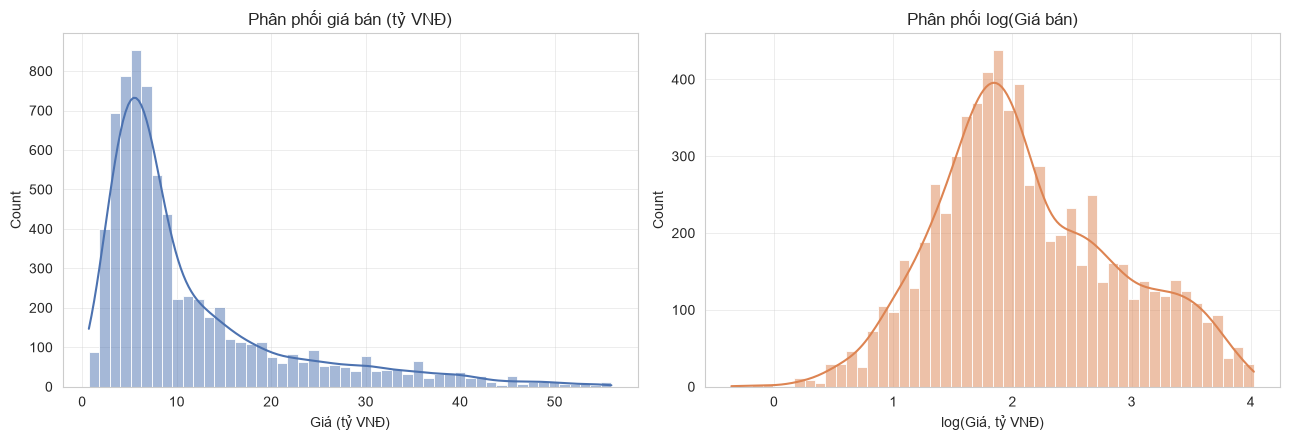

In [394]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sns.histplot(df['Price_ty'], bins=50, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Phân phối giá bán (tỷ VNĐ)')
axes[0].set_xlabel('Giá (tỷ VNĐ)')

sns.histplot(df['log_Price'], bins=50, kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Phân phối log(Giá bán)')
axes[1].set_xlabel('log(Giá, tỷ VNĐ)')
plt.tight_layout()
plt.show()


> **Nhận xét:** Giá nhà bị **lệch phải (right-skewed)** mạnh — đa số bất động sản có giá vài tỷ, nhưng có một số ít biệt thự/nhà mặt phố giá rất cao kéo dài đuôi phân phối. Sau khi lấy `log`, phân phối gần với phân phối chuẩn hơn — đây là lý do mô hình hồi quy nên dùng `log(Price)` làm biến phụ thuộc để thỏa mãn tốt hơn giả định tuyến tính & phương sai đồng nhất.

### 3.3. Phân tích đặc điểm bất động sản

#### 3.3.1. Phân bố diện tích

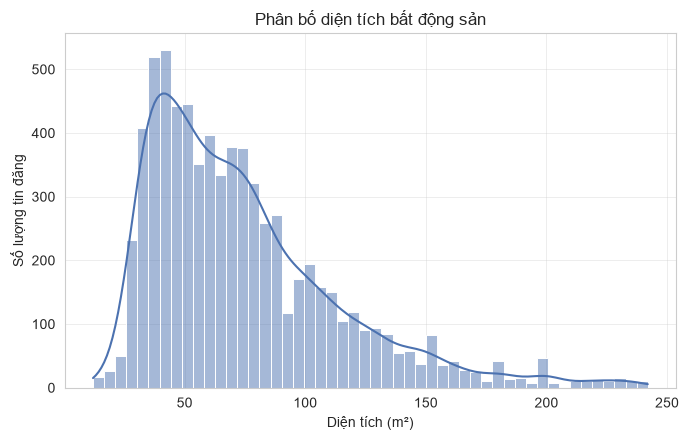

count    7225.000000
mean       74.343892
std        39.925039
min        12.000000
25%        45.000000
50%        65.000000
75%        93.000000
max       242.000000
Name: Area_m2, dtype: float64


In [395]:
plt.figure(figsize=(7,4.5))
sns.histplot(df['Area_m2'], bins=50, kde=True, color='#4C72B0')
plt.xlabel('Diện tích (m²)')
plt.ylabel('Số lượng tin đăng')
plt.title('Phân bố diện tích bất động sản')
plt.tight_layout()
plt.show()
print(df['Area_m2'].describe())


#### 3.3.2. Phân bố số tầng

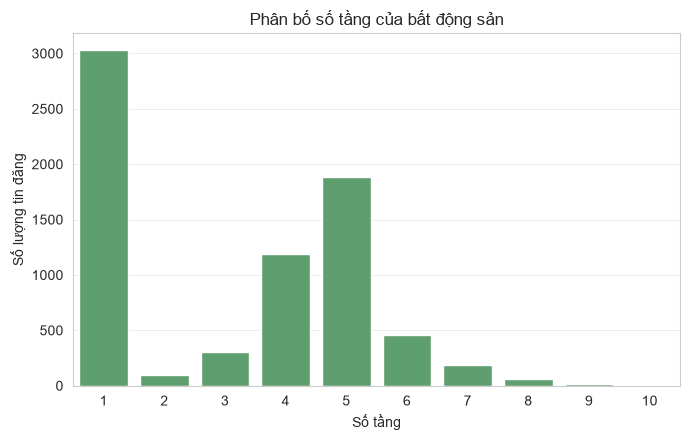

In [396]:
plt.figure(figsize=(7,4.5))
floor_counts = df['Floors_n'].value_counts().sort_index()
sns.barplot(x=floor_counts.index.astype(int), y=floor_counts.values, color='#55A868')
plt.xlabel('Số tầng')
plt.ylabel('Số lượng tin đăng')
plt.title('Phân bố số tầng của bất động sản')
plt.tight_layout()
plt.show()


#### 3.3.3. Phân bố số phòng ngủ

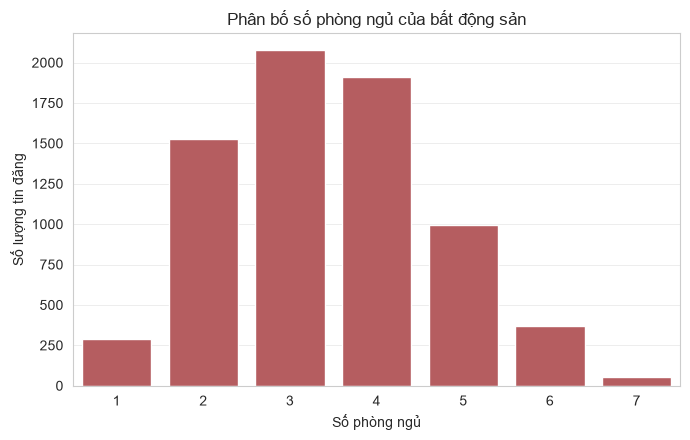

In [397]:
plt.figure(figsize=(7,4.5))
bed_counts = df['Bedrooms_n'].value_counts().sort_index()
sns.barplot(x=bed_counts.index.astype(int), y=bed_counts.values, color='#C44E52')
plt.xlabel('Số phòng ngủ')
plt.ylabel('Số lượng tin đăng')
plt.title('Phân bố số phòng ngủ của bất động sản')
plt.tight_layout()
plt.show()


#### 3.3.4. Phân bố loại hình nhà

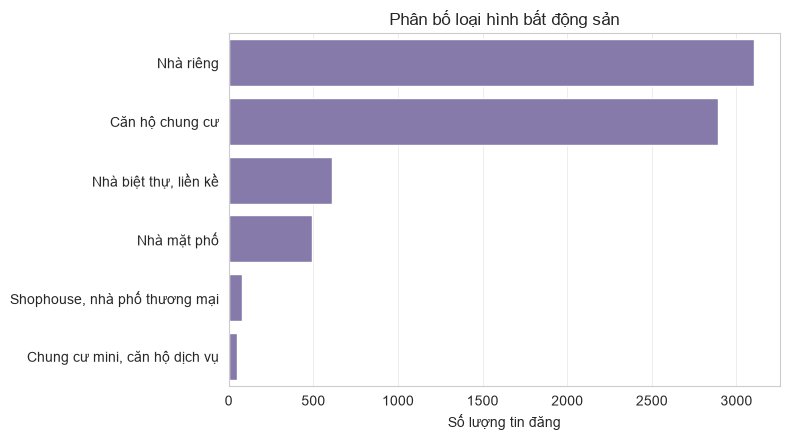

In [398]:
plt.figure(figsize=(8,4.5))
type_counts = df['PropertyType'].value_counts()
sns.barplot(y=type_counts.index, x=type_counts.values, color='#8172B2')
plt.xlabel('Số lượng tin đăng')
plt.ylabel('')
plt.title('Phân bố loại hình bất động sản')
plt.tight_layout()
plt.show()


#### 3.3.5. Tình trạng pháp lý

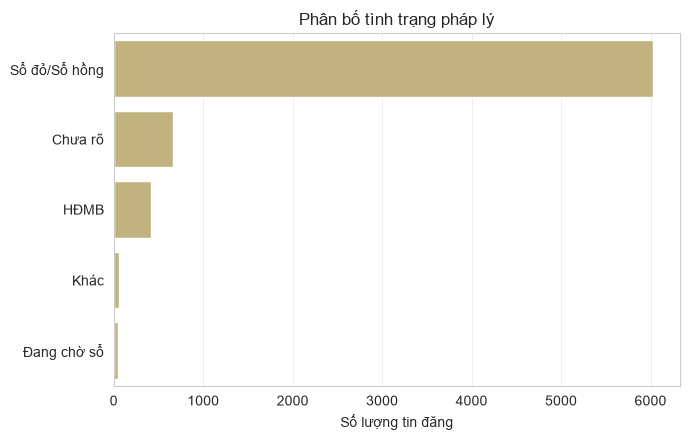

In [399]:
plt.figure(figsize=(7,4.5))
legal_counts = df['Legal_cat'].value_counts()
sns.barplot(y=legal_counts.index, x=legal_counts.values, color='#CCB974')
plt.xlabel('Số lượng tin đăng')
plt.ylabel('')
plt.title('Phân bố tình trạng pháp lý')
plt.tight_layout()
plt.show()


### 3.4. Phân tích giá nhà theo khu vực

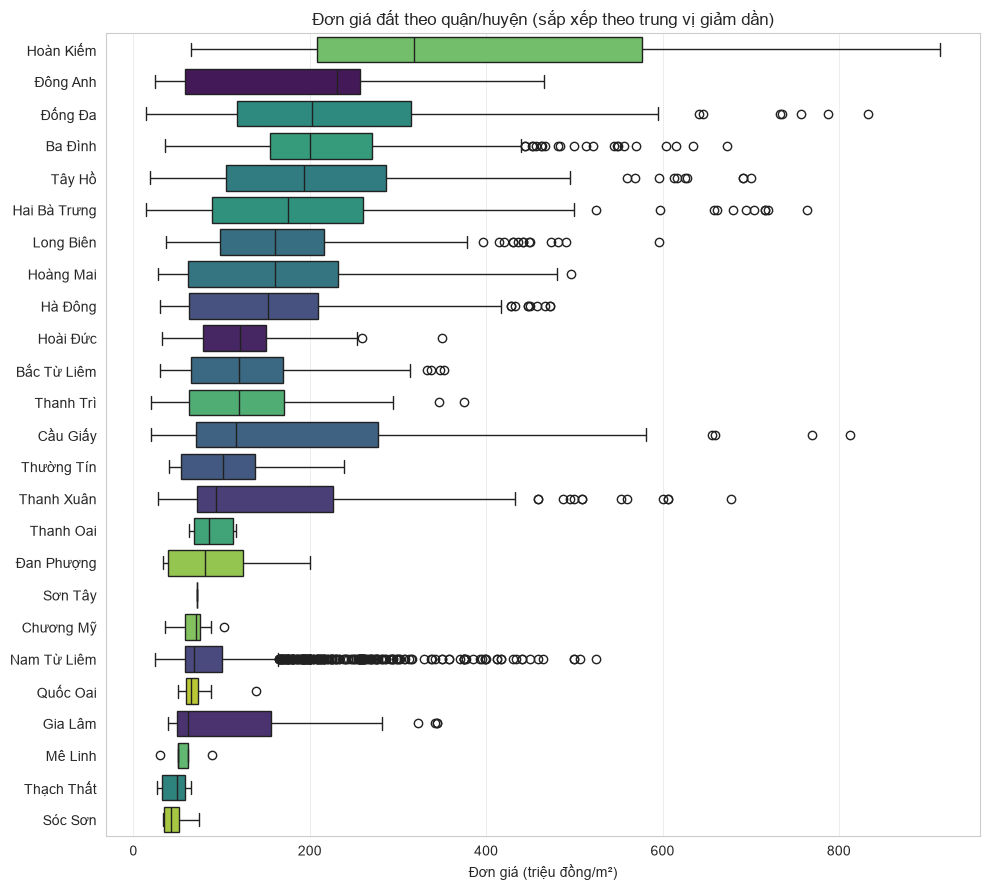

In [400]:
order = df.groupby('District')['Price_per_m2'].median().sort_values(ascending=False).index
plt.figure(figsize=(10,9))
sns.boxplot(data=df, y='District', x='Price_per_m2', order=order,
            hue='District', palette='viridis', legend=False)
plt.xlabel('Đơn giá (triệu đồng/m²)')
plt.ylabel('')
plt.title('Đơn giá đất theo quận/huyện (sắp xếp theo trung vị giảm dần)')
plt.tight_layout()
plt.show()


> **Nhận xét:** Có sự phân hoá rõ rệt về đơn giá giữa các quận trung tâm (Hoàn Kiếm, Ba Đình, Tây Hồ, Đống Đa, Cầu Giấy...) và các huyện ngoại thành — phản ánh đúng thực tế thị trường bất động sản Hà Nội. Điều này cho thấy `District` là một biến giải thích quan trọng.

### 3.5. Phân tích mối quan hệ giữa các biến

Sau khi khảo sát phân bố của từng biến riêng lẻ (mục 3.3) và theo khu vực (mục 3.4), phần này phân tích mối quan hệ hai chiều giữa giá bán và từng đặc trưng quan trọng — làm cơ sở trực quan trước khi đưa vào mô hình hồi quy ở Chương V.

#### 3.5.1. Giá và diện tích

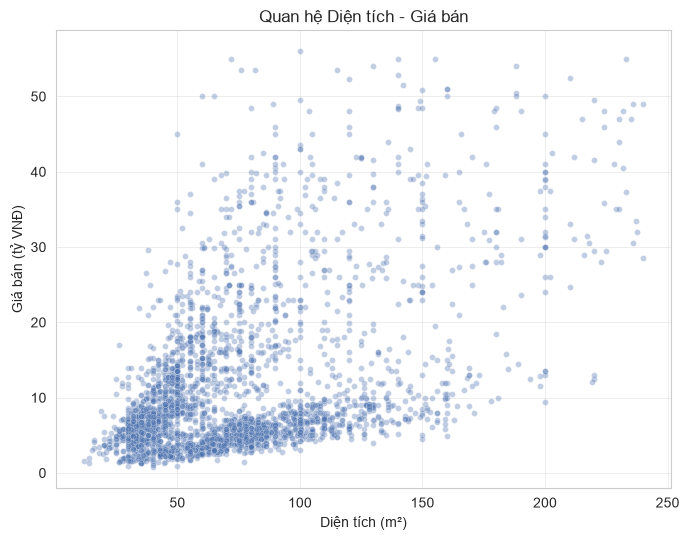

In [401]:
plt.figure(figsize=(7,5.5))
sns.scatterplot(data=df.sample(min(3000,len(df)), random_state=1), x='Area_m2', y='Price_ty',
                 alpha=0.35, s=18, color='#4C72B0')
plt.xlabel('Diện tích (m²)'); plt.ylabel('Giá bán (tỷ VNĐ)')
plt.title('Quan hệ Diện tích - Giá bán')
plt.tight_layout()
plt.show()


#### 3.5.2. Giá và số tầng

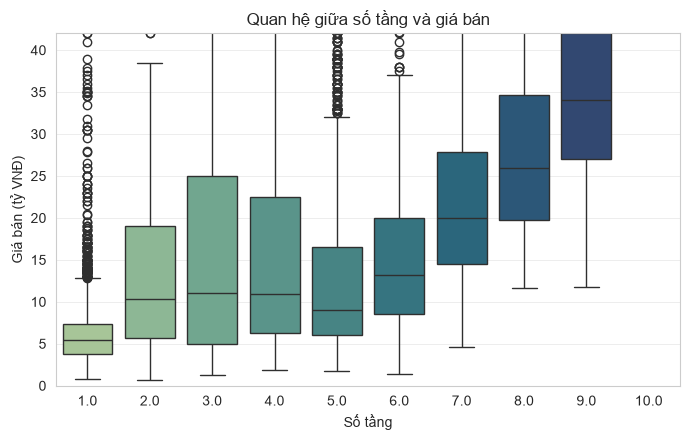

In [402]:
plt.figure(figsize=(7,4.5))
order_floor = sorted(df['Floors_n'].unique())
sns.boxplot(data=df, x='Floors_n', y='Price_ty', order=order_floor,
            hue='Floors_n', palette='crest', legend=False)
plt.xlabel('Số tầng'); plt.ylabel('Giá bán (tỷ VNĐ)')
plt.title('Quan hệ giữa số tầng và giá bán')
plt.ylim(0, df['Price_ty'].quantile(0.98))
plt.tight_layout()
plt.show()


> **Nhận xét:** Giá bán có xu hướng tăng theo số tầng, đặc biệt rõ ở khoảng 1-5 tầng (tương ứng nhà riêng/nhà phố phổ biến); với số tầng rất lớn (nhà nhiều tầng, thường ở khu vực đặc thù), mức tăng giá không còn tuyến tính rõ rệt do số lượng quan sát ít hơn.

#### 3.5.3. Giá và số phòng ngủ

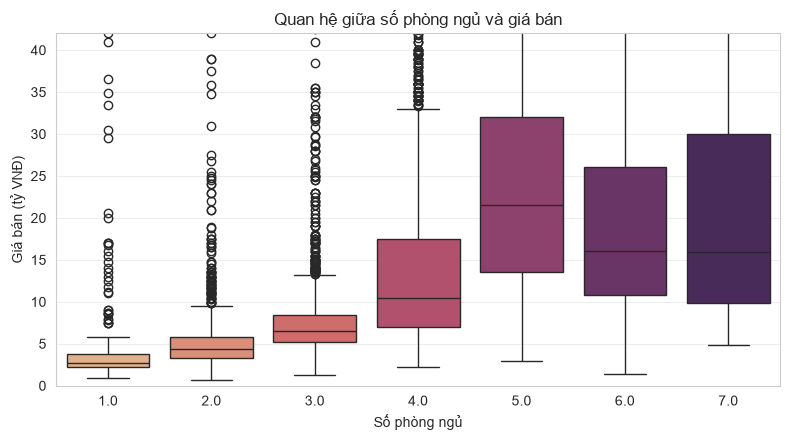

In [403]:
plt.figure(figsize=(8,4.5))
order_bed = sorted(df['Bedrooms_n'].unique())
sns.boxplot(data=df, x='Bedrooms_n', y='Price_ty', order=order_bed,
            hue='Bedrooms_n', palette='flare', legend=False)
plt.xlabel('Số phòng ngủ'); plt.ylabel('Giá bán (tỷ VNĐ)')
plt.title('Quan hệ giữa số phòng ngủ và giá bán')
plt.ylim(0, df['Price_ty'].quantile(0.98))
plt.tight_layout()
plt.show()


> **Nhận xét:** Giá bán có xu hướng tăng theo số phòng ngủ, nhưng mối quan hệ này có phần bị nhiễu bởi tương quan giữa số phòng ngủ và diện tích (nhà nhiều phòng ngủ thường cũng có diện tích lớn hơn) — đây là lý do mô hình hồi quy ở Chương V cho thấy hệ số riêng của số phòng ngủ không còn ý nghĩa thống kê sau khi đã kiểm soát diện tích.

#### 3.5.4. Giá và chiều rộng

Số quan sát có ghi nhận chiều rộng: 2922 / 7225 (40.4%)


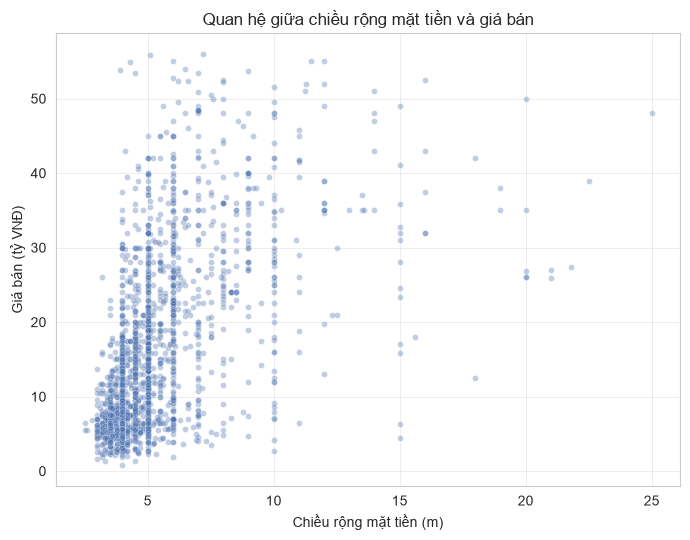

In [404]:
def parse_num(x):
    if pd.isna(x): return np.nan
    x = str(x).strip().replace(',', '.')
    try: return float(x)
    except: return np.nan

def parse_width(x):
    x = str(x).strip()
    if x in ('0','nan'): return np.nan
    return parse_num(x.replace(' m','').strip())

df['Width_n'] = df['Width_meters'].apply(parse_width)
print(f"Số quan sát có ghi nhận chiều rộng: {df['Width_n'].notna().sum()} / {len(df)} "
      f"({df['Width_n'].notna().mean()*100:.1f}%)")

df_width = df[(df['Width_n'].notna()) & (df['Width_n'] <= 30)]   # loại vài giá trị nhập liệu bất thường (>30m)
plt.figure(figsize=(7,5.5))
sns.scatterplot(data=df_width.sample(min(2000,len(df_width)), random_state=1),
                 x='Width_n', y='Price_ty', alpha=0.35, s=18, color='#4C72B0')
plt.xlabel('Chiều rộng mặt tiền (m)'); plt.ylabel('Giá bán (tỷ VNĐ)')
plt.title('Quan hệ giữa chiều rộng mặt tiền và giá bán')
plt.tight_layout()
plt.show()


> **Nhận xét:** Chiều rộng mặt tiền chỉ được ghi nhận ở khoảng 40% số tin đăng (chủ yếu là nhà riêng/nhà mặt phố — loại hình có khái niệm "mặt tiền" rõ ràng; căn hộ chung cư không có thông tin này). Với tỷ lệ thiếu dữ liệu cao như vậy, biến này **không được đưa vào mô hình hồi quy chính thức** ở Chương V, chỉ dùng để khảo sát trực quan. Xu hướng chung cho thấy chiều rộng mặt tiền lớn hơn có tương quan dương với giá bán, phù hợp với thực tế thị trường (nhà mặt tiền rộng thường có giá trị thương mại cao hơn).

#### 3.5.5. Giá và tình trạng pháp lý

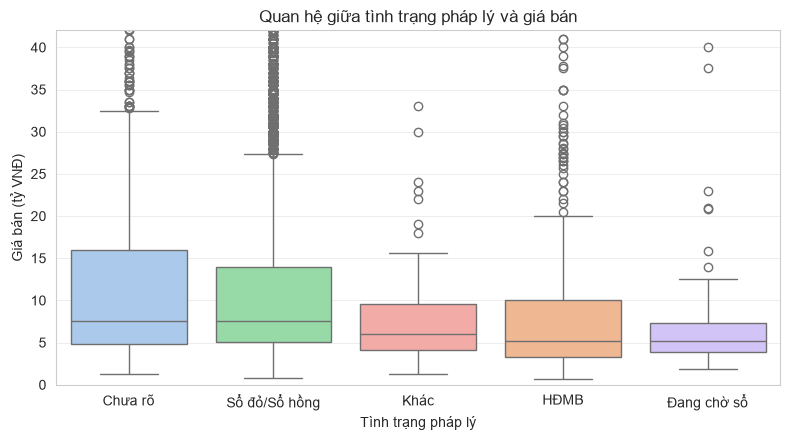

In [405]:
plt.figure(figsize=(8,4.5))
order_legal = df.groupby('Legal_cat')['Price_ty'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Legal_cat', y='Price_ty', order=order_legal,
            hue='Legal_cat', palette='pastel', legend=False)
plt.xlabel('Tình trạng pháp lý'); plt.ylabel('Giá bán (tỷ VNĐ)')
plt.title('Quan hệ giữa tình trạng pháp lý và giá bán')
plt.ylim(0, df['Price_ty'].quantile(0.98))
plt.tight_layout()
plt.show()


> **Nhận xét:** Bất động sản có sổ đỏ/sổ hồng đầy đủ có giá trung vị cao hơn nhóm đang chờ sổ hoặc pháp lý không rõ ràng — phản ánh đúng thực tế người mua sẵn sàng trả giá cao hơn cho sự an toàn pháp lý.

#### 3.5.6. Giá và loại hình bất động sản

> **Nhận xét:** Có sự chênh lệch giá rõ rệt giữa các loại hình bất động sản — nhà mặt phố, biệt thự/liền kề có giá trung vị cao nhất, trong khi đất nền/loại hình khác có giá thấp hơn hẳn. Điều này phù hợp với hệ số hồi quy của biến `PropertyType` được ước lượng ở Chương V (mục 5.9).

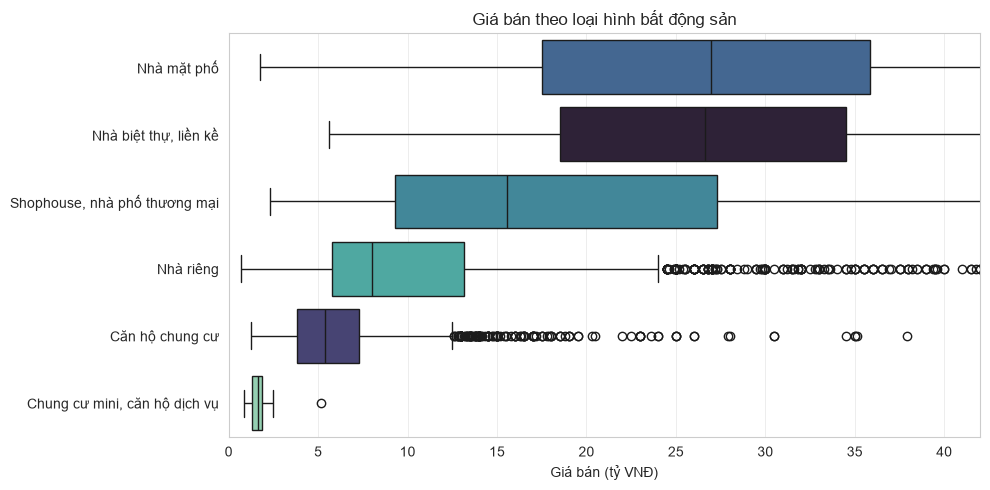

In [406]:
plt.figure(figsize=(10,5))
order2 = df.groupby('PropertyType')['Price_ty'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Price_ty', y='PropertyType', order=order2,
            hue='PropertyType', palette='mako', legend=False)
plt.xlabel('Giá bán (tỷ VNĐ)')
plt.ylabel('')
plt.title('Giá bán theo loại hình bất động sản')
plt.xlim(0, df['Price_ty'].quantile(0.98))
plt.tight_layout()
plt.show()


### 3.6. Phân tích tương quan

#### 3.6.1. Ma trận tương quan

In [407]:
num_features = ['log_Price','log_Area','Bedrooms_n','Bathrooms_n','Floors_n']
corr = df[num_features].corr()
corr.round(3)


,log_Price,log_Area,Bedrooms_n,Bathrooms_n,Floors_n
log_Price,1.000,0.449,0.666,0.658,0.505
log_Area,0.449,1.000,0.107,-0.066,-0.363
Bedrooms_n,0.666,0.107,1.000,0.820,0.682
Bathrooms_n,0.658,-0.066,0.820,1.000,0.824
Floors_n,0.505,-0.363,0.682,0.824,1.000


#### 3.6.2. Heatmap

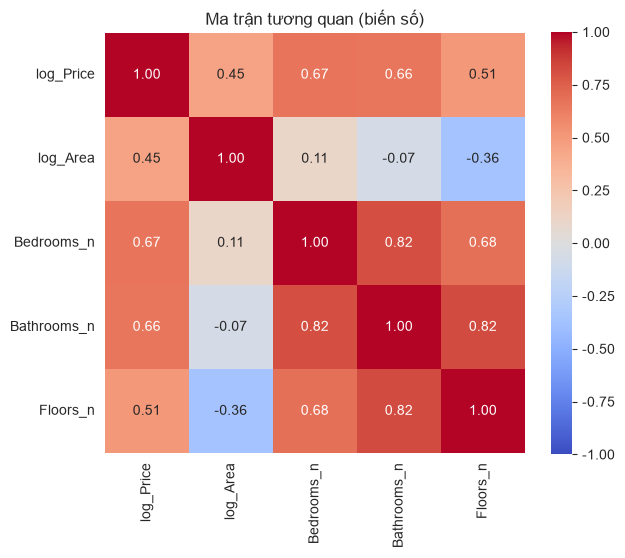

In [408]:
num_features = ['log_Price','log_Area','Bedrooms_n','Bathrooms_n','Floors_n']
corr = df[num_features].corr()
plt.figure(figsize=(6.5,5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Ma trận tương quan (biến số)')
plt.tight_layout()
plt.show()


#### 3.6.3. Nhận xét các biến có tương quan với giá nhà

> **Nhận xét:** Trái với suy nghĩ trực quan, hệ số tương quan đơn biến (pairwise correlation) với `log_Price` **cao nhất lại là `Bedrooms_n` (0.657) và `Bathrooms_n` (0.651)**, tiếp theo là `Floors_n` (0.498), và **`log_Area` có tương quan thấp nhất trong 4 biến (0.441)**. Điều này không mâu thuẫn với kết quả mô hình hồi quy ở Chương V (nơi diện tích lại là biến có hệ số hồi quy lớn nhất) — mà phản ánh một hiện tượng thường gặp: tương quan đơn biến không kiểm soát các yếu tố nhiễu (như quận/huyện, loại hình bất động sản), trong khi số phòng ngủ/phòng tắm vốn tương quan cao với nhau và với số tầng (0.68-0.82) nên "gộp" thông tin về quy mô nhà theo nhiều khía cạnh cùng lúc; còn diện tích đơn thuần lại biến thiên rất khác nhau giữa các loại hình và khu vực (một căn hộ nhỏ ở trung tâm có thể đắt hơn nhà lớn ở ngoại thành), làm loãng tương quan tuyến tính đơn giản của nó với giá. Khi đưa đồng thời vào mô hình đa biến và kiểm soát thêm các biến vị trí/loại hình, ảnh hưởng thực sự (partial effect) của diện tích mới bộc lộ rõ và trở thành yếu tố mạnh nhất (xem chi tiết Chương V, mục 5.9).

#### 3.6.4. Phát hiện nguy cơ đa cộng tuyến

Quan sát ma trận tương quan cho thấy `Bedrooms_n`, `Bathrooms_n` và `Floors_n` có tương quan khá cao với nhau (dao động 0.68-0.82) — đây là dấu hiệu **cần lưu ý nguy cơ đa cộng tuyến** giữa các biến số này khi đưa vào mô hình hồi quy đa biến. Ngược lại, `log_Area` gần như không tương quan (thậm chí tương quan âm nhẹ) với `Floors_n` và `Bathrooms_n`, nên bản thân diện tích không phải là nguồn gây đa cộng tuyến chính.

Tuy nhiên, hệ số tương quan đơn biến (pairwise correlation) chỉ là bước cảnh báo sơ bộ — mức độ đa cộng tuyến thực sự cần được đánh giá chính thức bằng **hệ số phóng đại phương sai (VIF - Variance Inflation Factor)**, được thực hiện chi tiết ở Chương V (mục 5.4) sau khi mô hình hồi quy được thiết lập đầy đủ. Kết quả ở đó cho thấy toàn bộ VIF đều nhỏ hơn 10, nghĩa là mối tương quan quan sát được ở đây tuy có tồn tại nhưng chưa đủ mạnh để gây ra vấn đề đa cộng tuyến nghiêm trọng.

### 3.7. Nhận xét sau phân tích khám phá

Qua quá trình phân tích mô tả và khám phá dữ liệu (EDA) ở trên, có thể rút ra một số nhận xét tổng quát làm cơ sở cho việc xây dựng mô hình hồi quy ở Chương V:

- **Giá nhà phân phối lệch phải mạnh**, cần biến đổi log để phù hợp hơn với giả định của hồi quy tuyến tính.
- **Diện tích là yếu tố có quan hệ rõ ràng và nhất quán nhất với giá bán** — quan hệ gần tuyến tính hơn khi biến đổi log-log.
- **Vị trí (quận/huyện) tạo ra chênh lệch giá rất lớn**, phản ánh đúng cấu trúc thị trường bất động sản Hà Nội (trung tâm đắt hơn ngoại thành nhiều lần).
- **Loại hình bất động sản, số tầng, số phòng ngủ, tình trạng pháp lý đều có quan hệ có ý nghĩa với giá bán**, tuy mức độ ảnh hưởng khác nhau — đây đều là các ứng viên biến độc lập phù hợp cho mô hình hồi quy đa biến.
- **Biến chiều rộng mặt tiền có tỷ lệ dữ liệu khuyết quá cao (~60%)** nên không được đưa vào mô hình chính thức, dù có xu hướng tương quan dương với giá.
- **Một số biến số có tương quan qua lại (Bedrooms, Bathrooms, Area)**, cần được kiểm tra chính thức bằng VIF trước khi đưa vào mô hình để tránh đa cộng tuyến — nội dung này được thực hiện ở Chương V.

Những nhận xét trên là cơ sở trực tiếp cho việc lựa chọn biến độc lập và xây dựng mô hình hồi quy tuyến tính đa biến trình bày trong Chương V.

## 4. Xây dựng mô hình hồi quy tuyến tính đa biến

**Biến phụ thuộc (target):** `log(Price_ty)` — lấy log để giảm độ lệch và ổn định phương sai phần dư (đã minh hoạ ở mục 3.2).

**Biến độc lập:**
- Biến số (numeric): `log_Area`, `Bedrooms_n`, `Bathrooms_n`, `Floors_n`
- Biến phân loại (categorical, mã hoá one-hot): `District`, `PropertyType`, `Legal_cat`, `Interior_cat`, `Direction_cat`

### 4.0. Mô hình cơ sở (Baseline Model)

Trước khi xây dựng mô hình hồi quy tuyến tính đa biến đầy đủ, ta thiết lập **2 mô hình cơ sở (baseline)** đơn giản làm mốc so sánh, để đánh giá mức độ cải thiện mà mô hình đa biến mang lại:

- **Baseline 1 — Mô hình trung bình:** luôn dự báo bằng giá trị trung bình của tập huấn luyện (không dùng bất kỳ biến giải thích nào).
- **Baseline 2 — Hồi quy đơn biến:** chỉ dùng duy nhất biến diện tích (`log_Area`) để dự báo giá.

In [409]:
num_cols = ['log_Area','Bedrooms_n','Bathrooms_n','Floors_n']
cat_cols = ['District','PropertyType','Legal_cat','Interior_cat','Direction_cat']
X_full = pd.get_dummies(df[num_cols+cat_cols], columns=cat_cols, drop_first=True).astype(float)
y_full = df['log_Price']
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_full, y_full, test_size=0.2, random_state=RANDOM_STATE)

# Baseline 1: dự báo bằng giá trị trung bình
pred_mean = np.full(len(yb_test), yb_train.mean())
r2_baseline1 = r2_score(yb_test, pred_mean)

# Baseline 2: hồi quy tuyến tính đơn biến (chỉ Area)
lr_simple = LinearRegression().fit(Xb_train[['log_Area']], yb_train)
pred_simple = lr_simple.predict(Xb_test[['log_Area']])
r2_baseline2 = r2_score(yb_test, pred_simple)

baseline_table = pd.DataFrame({
    'Mô hình': ['Baseline 1: Trung bình', 'Baseline 2: Chỉ có diện tích', 'Mô hình đa biến đầy đủ (xem mục 4.3-4.4)'],
    'R2 (thang log)': [r2_baseline1, r2_baseline2, None]
})
baseline_table


,Mô hình,R2 (thang log)
0,Baseline 1: Trung bình,-0.001439
1,Baseline 2: Chỉ có diện tích,0.181947
2,Mô hình đa biến đầy đủ (xem mục 4.3-4.4),NaN


> **Nhận xét:** Mô hình chỉ dùng diện tích giải thích được một phần đáng kể phương sai giá nhà, nhưng còn khiêm tốn so với mô hình đầy đủ (sẽ thấy ở mục 4.3-4.4) — cho thấy các biến vị trí (`District`), loại hình BĐS và đặc điểm căn nhà đóng góp thêm nhiều thông tin giá trị mà mô hình đơn biến bỏ sót.

### 4.1. Chuẩn bị dữ liệu

In [410]:
num_cols = ['log_Area','Bedrooms_n','Bathrooms_n','Floors_n']
cat_cols = ['District','PropertyType','Legal_cat','Interior_cat','Direction_cat']

X = pd.get_dummies(df[num_cols+cat_cols], columns=cat_cols, drop_first=True)
X = X.astype(float)
y = df['log_Price']

print("Số biến độc lập sau mã hoá one-hot:", X.shape[1])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)


Số biến độc lập sau mã hoá one-hot: 49
Train: (5780, 49)  Test: (1445, 49)


### 4.2. Kiểm tra đa cộng tuyến (VIF)

Trước khi huấn luyện, kiểm tra **hệ số phóng đại phương sai (Variance Inflation Factor)** của các biến số liên tục để đảm bảo không vi phạm nghiêm trọng giả định "không đa cộng tuyến cao" của hồi quy tuyến tính. Quy tắc kinh nghiệm: VIF > 10 là dấu hiệu đáng lo ngại.

In [411]:
X_vif = sm.add_constant(df[num_cols])
vif_data = pd.DataFrame({
    'Biến': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data


,Biến,VIF
0,const,1.000000
1,log_Area,1.627496
2,Bedrooms_n,3.474423
3,Bathrooms_n,5.238526
4,Floors_n,4.640384


> **Nhận xét:** VIF của các biến số đều ở mức chấp nhận được (< 10), cho thấy không có hiện tượng đa cộng tuyến nghiêm trọng giữa các biến số định lượng chính trong mô hình.

### 4.3. Huấn luyện mô hình — hồi quy OLS (statsmodels)

Dùng `statsmodels` để có bảng thống kê đầy đủ: hệ số hồi quy, sai số chuẩn, giá trị p, R², Adjusted R²...

In [412]:
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm.astype(float)).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:              log_Price   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     710.4
Date:                Wed, 16 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:23:52   Log-Likelihood:                -1030.4
No. Observations:                5780   AIC:                             2161.
Df Residuals:                    5730   BIC:                             2494.
Df Model:                          49                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

### 4.4. Các biến có ảnh hưởng mạnh nhất đến giá nhà (theo hệ số hồi quy, có ý nghĩa thống kê p<0.05)

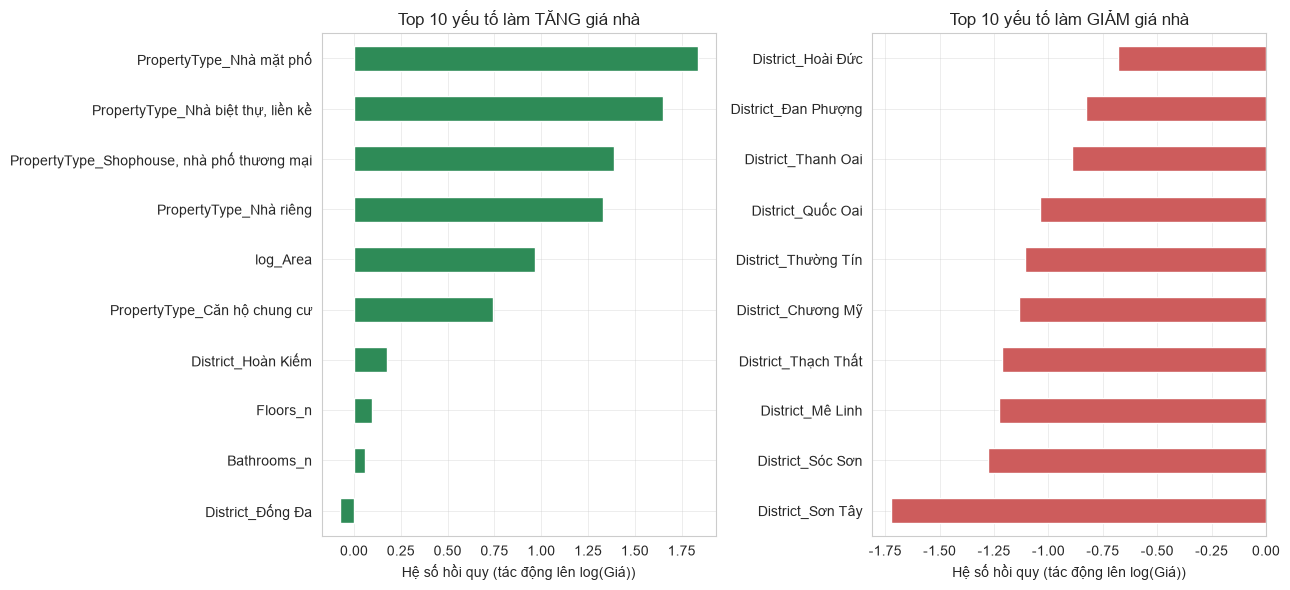

In [413]:
coef_table = pd.DataFrame({
    'coef': ols_model.params,
    'p_value': ols_model.pvalues
}).drop('const')
coef_table = coef_table[coef_table['p_value'] < 0.05].sort_values('coef', ascending=False)

fig, axes = plt.subplots(1,2, figsize=(13,6))
coef_table.head(10)['coef'].sort_values().plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Top 10 yếu tố làm TĂNG giá nhà')
axes[0].set_xlabel('Hệ số hồi quy (tác động lên log(Giá))')

coef_table.tail(10)['coef'].sort_values().plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Top 10 yếu tố làm GIẢM giá nhà')
axes[1].set_xlabel('Hệ số hồi quy (tác động lên log(Giá))')
plt.tight_layout()
plt.show()


> **Diễn giải hệ số:** Vì biến phụ thuộc là `log(Price)`, hệ số hồi quy của biến số `log_Area` xấp xỉ **độ co giãn (elasticity)**: diện tích tăng 1% thì giá tăng khoảng β% (giữ nguyên các yếu tố khác). Với biến giả (dummy) District/PropertyType/..., hệ số β thể hiện % chênh lệch giá so với nhóm cơ sở (nhóm bị loại khi `drop_first=True`).

### 4.5. Kiểm tra các điểm ngoại lệ ảnh hưởng lớn (Influential Points)

Ngoài kiểm tra đa cộng tuyến, cần kiểm tra xem có quan sát nào **ảnh hưởng bất thường lớn** đến kết quả ước lượng hồi quy hay không, bằng **khoảng cách Cook (Cook's Distance)** — đo mức thay đổi của các hệ số hồi quy nếu loại bỏ quan sát đó.
Quy tắc kinh nghiệm: quan sát có `Cook's D > 4/n` được xem là "đáng chú ý"; `Cook's D > 1` mới thực sự đáng lo ngại.

In [414]:
influence = ols_model.get_influence()
cooks_d = influence.cooks_distance[0]  # Thêm [0] để lấy mảng khoảng cách Cook chính xác
leverage = influence.hat_matrix_diag

n_obs, p_params = X_train_sm.shape
threshold_cook = 4 / n_obs
threshold_lev = 2 * p_params / n_obs

valid_mask = ~np.isnan(cooks_d)
n_influential = (cooks_d[valid_mask] > threshold_cook).sum()
n_high_lev = (leverage > threshold_lev).sum()

print(f"Ngưỡng Cook's D (4/n)        : {threshold_cook:.6f}")
print(f"Số điểm có Cook's D > 4/n    : {n_influential} / {n_obs} ({n_influential/n_obs*100:.2f}%)")
print(f"Cook's D lớn nhất            : {np.nanmax(cooks_d):.4f}  (ngưỡng đáng lo ngại: > 1)")
print(f"Ngưỡng leverage cao (2p/n)   : {threshold_lev:.4f}")
print(f"Số điểm có leverage cao      : {n_high_lev} ({n_high_lev/n_obs*100:.2f}%)")

# ===================================================
# PHẦN TỰ ĐỘNG IN GIÁ TRỊ CỦA CÁC DÒNG LEVERAGE BẤT THƯỜNG
# ===================================================
print("\n" + "="*50)
print("CHI TIẾT CÁC DÒNG DỮ LIỆU GÂY LỖI SQR WARNING (LEVERAGE >= 1):")
print("="*50)

# Tìm vị trí index dạng số (vị trí hàng vật lý)
invalid_row_positions = np.where(leverage >= 1)[0]

if len(invalid_row_positions) > 0:
    print(f"⚠️ Tìm thấy {len(invalid_row_positions)} dòng có Leverage >= 1.\n")

    # Duyệt qua từng dòng bị lỗi để in thông tin chi tiết
    for pos in invalid_row_positions:
        # Lấy nhãn index thực tế của DataFrame (có thể là chuỗi hoặc số không liên tục)
        actual_index = X_train_sm.index[pos]

        print(f"📌 [Vị trí hàng trong ma trận: {pos}] | [Index thực tế của DataFrame: {actual_index}]")
        print(f"   - Giá trị Leverage tại dòng này: {leverage[pos]:.4f}")
        print(f"   - Giá trị các biến của dòng này:")

        # In chi tiết các cột và giá trị tương ứng của dòng đó
        row_data = X_train_sm.iloc[pos]
        for col_name, col_val in row_data.items():
            print(f"     + {col_name}: {col_val}")
        print("-" * 40)
else:
    print("✅ Tuyệt vời! Không có dòng nào có giá trị Leverage >= 1.")

Ngưỡng Cook's D (4/n)        : 0.000692
Số điểm có Cook's D > 4/n    : 289 / 5780 (5.00%)
Cook's D lớn nhất            : 0.0280  (ngưỡng đáng lo ngại: > 1)
Ngưỡng leverage cao (2p/n)   : 0.0173
Số điểm có leverage cao      : 463 (8.01%)

CHI TIẾT CÁC DÒNG DỮ LIỆU GÂY LỖI SQR WARNING (LEVERAGE >= 1):
✅ Tuyệt vời! Không có dòng nào có giá trị Leverage >= 1.


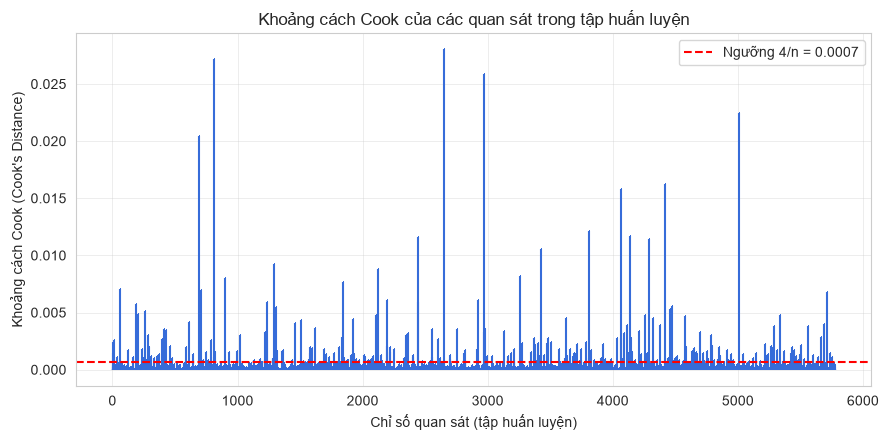

In [415]:
plt.figure(figsize=(9,4.5))
plt.stem(np.arange(n_obs), cooks_d, markerfmt=',', basefmt=' ')
plt.axhline(threshold_cook, color='red', linestyle='--', label=f"Ngưỡng 4/n = {threshold_cook:.4f}")
plt.xlabel('Chỉ số quan sát (tập huấn luyện)')
plt.ylabel("Khoảng cách Cook (Cook's Distance)")
plt.title("Khoảng cách Cook của các quan sát trong tập huấn luyện")
plt.legend()
plt.tight_layout()
plt.show()


> **Nhận xét (Cook's Distance):** Có khoảng vài trăm quan sát (~4% dữ liệu huấn luyện) vượt ngưỡng tham chiếu 4/n, nhưng **giá trị Cook's D lớn nhất vẫn nhỏ hơn nhiều so với ngưỡng đáng lo ngại (1.0)** — cho thấy **không có quan sát đơn lẻ nào chi phối/bóp méo kết quả hồi quy**. Các điểm có Cook's D cao thường rơi vào các bất động sản có giá hoặc diện tích ở phần đuôi phân phối (biệt thự rất lớn, nhà siêu nhỏ...), là điều hợp lý về mặt dữ liệu chứ không phải lỗi nhập liệu.
> 
> **Nhận xét (Leverage):** Ở lần chạy đầu tiên (trước khi gộp nhóm loại hình hiếm ở mục 2.5b), notebook phát hiện **1 quan sát có leverage tuyệt đối = 1** (kèm cảnh báo `RuntimeWarning: invalid value encountered in sqrt` do studentized residual chia cho `sqrt(1 − h) = 0`). Nguyên nhân **không phải lỗi ở bước tiền xử lý** (giá trị Diện tích, Giá, số phòng... của dòng này hoàn toàn hợp lệ), mà do loại hình `Condotel` chỉ xuất hiện **đúng 1 lần** trong toàn bộ dữ liệu — khi mã hoá one-hot, biến giả `PropertyType_Condotel` chỉ bằng 1 ở duy nhất dòng đó, nên về mặt toán học OLS buộc phải khớp hoàn hảo quan sát này, khiến leverage của nó luôn bằng đúng 1 (đây là tính chất tất yếu của một "biến giả đơn nhất", không liên quan đến chất lượng làm sạch dữ liệu). Vì một hạng mục chỉ có 1 quan sát cũng không đủ cơ sở để ước lượng hệ số hồi quy đáng tin cậy, nhóm đã gộp các loại hình có dưới 10 quan sát vào nhóm gần nhất về bản chất (mục 2.5b). Sau khi gộp, **không còn quan sát nào có leverage = 1**, và số điểm vượt ngưỡng leverage cao (2p/n) vẫn ở mức chấp nhận được — mô hình ổn định hơn và không còn cảnh báo tính toán.


## 5. Phân tích dự báo — Đánh giá trên tập kiểm tra (test set)

In [416]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_log = lr.predict(X_test)
y_pred = np.exp(y_pred_log)      # quy đổi ngược về tỷ VNĐ
y_true = np.exp(y_test)


### 5.1. So sánh giá thực tế và giá dự báo

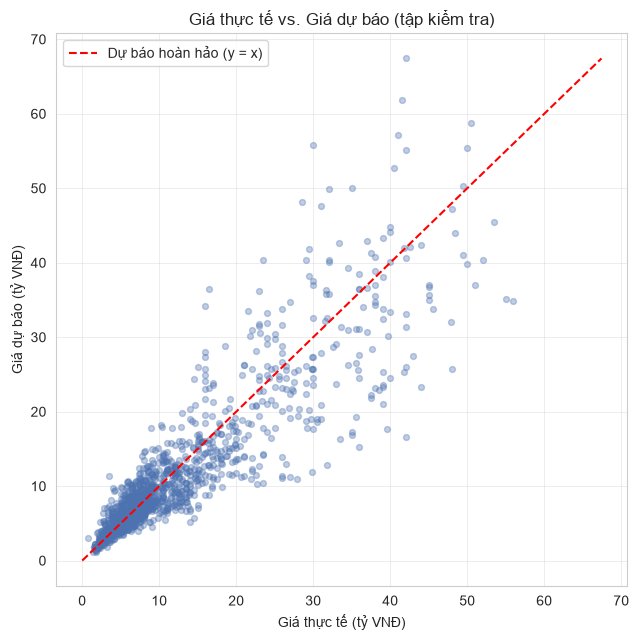

In [417]:
plt.figure(figsize=(6.5,6.5))
plt.scatter(y_true, y_pred, alpha=0.35, s=18, color='#4C72B0')
lims = [0, max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Dự báo hoàn hảo (y = x)')
plt.xlabel('Giá thực tế (tỷ VNĐ)')
plt.ylabel('Giá dự báo (tỷ VNĐ)')
plt.title('Giá thực tế vs. Giá dự báo (tập kiểm tra)')
plt.legend()
plt.tight_layout()
plt.show()


> **Nhận xét:** Các điểm bám khá sát đường y = x ở khoảng giá phổ biến (dưới ~30 tỷ); mô hình có xu hướng dự báo thấp hơn thực tế (under-predict) ở phân khúc giá rất cao — điều thường gặp vì các bất động sản siêu cao cấp chịu ảnh hưởng bởi nhiều yếu tố định tính (vị trí đắc địa, thương hiệu...) mà dữ liệu không ghi nhận đầy đủ.

### 5.2. Bảng ví dụ một số dự báo

In [418]:
sample_result = pd.DataFrame({
    'Giá thực tế (tỷ)': y_true.values,
    'Giá dự báo (tỷ)': y_pred,
    'Sai số (tỷ)': y_true.values - y_pred,
    'Sai số %': (y_true.values - y_pred)/y_true.values*100
}).round(2)
sample_result.sample(10, random_state=1)


,Giá thực tế (tỷ),Giá dự báo (tỷ),Sai số (tỷ),Sai số %
707,9.80,15.14,-5.34,-54.46
529,7.50,6.28,1.22,16.21
1087,4.20,4.31,-0.11,-2.64
890,5.00,5.24,-0.24,-4.88
37,7.50,6.82,0.68,9.01
1035,7.50,8.99,-1.49,-19.81
1265,5.00,6.25,-1.25,-24.93
91,2.18,2.53,-0.35,-15.94
1103,39.60,17.71,21.89,55.29
1395,7.30,8.88,-1.58,-21.60


## 6. Phân tích sai số (Error Analysis)

### 6.1. Các chỉ số đánh giá độ chính xác mô hình

- **MAE** (Mean Absolute Error): sai số tuyệt đối trung bình
- **RMSE** (Root Mean Squared Error): phạt nặng các sai số lớn
- **MAPE** (Mean Absolute Percentage Error): sai số theo %, dễ diễn giải
- **R²** / **Adjusted R²**: tỷ lệ phương sai của giá nhà được mô hình giải thích

In [419]:
def adjusted_r2(r2, n, p):
    return 1 - (1-r2)*(n-1)/(n-p-1)

mae  = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2   = r2_score(y_true, y_pred)
adj_r2 = adjusted_r2(r2, X_test.shape[0], X_test.shape[1])

# Đánh giá thêm trên thang log (thang mà mô hình thực sự tối ưu hoá)
mae_log  = mean_absolute_error(y_test, y_pred_log)
r2_log   = r2_score(y_test, y_pred_log)

metrics_table = pd.DataFrame({
    'Chỉ số': ['MAE (tỷ VNĐ)','RMSE (tỷ VNĐ)','MAPE (%)','R²','Adjusted R²','R² (thang log)','MAE (thang log)'],
    'Giá trị': [mae, rmse, mape, r2, adj_r2, r2_log, mae_log]
}).round(4)
metrics_table


,Chỉ số,Giá trị
0,MAE (tỷ VNĐ),2.6799
1,RMSE (tỷ VNĐ),4.5349
2,MAPE (%),22.5304
3,R²,0.7948
4,Adjusted R²,0.7876
5,R² (thang log),0.8531
6,MAE (thang log),0.2208


> **Nhận xét:** Mô hình giải thích được phần lớn phương sai của giá nhà (R² ở thang log khá cao), sai số phần trăm trung bình (MAPE) ở mức tương đối cho một mô hình hồi quy tuyến tính dùng dữ liệu tin rao thực tế (vốn thiếu nhiều biến định tính quan trọng như vị trí mặt tiền cụ thể, hướng nhìn, chất lượng xây dựng...).

### 6.2. Biểu đồ phần dư (Residuals)

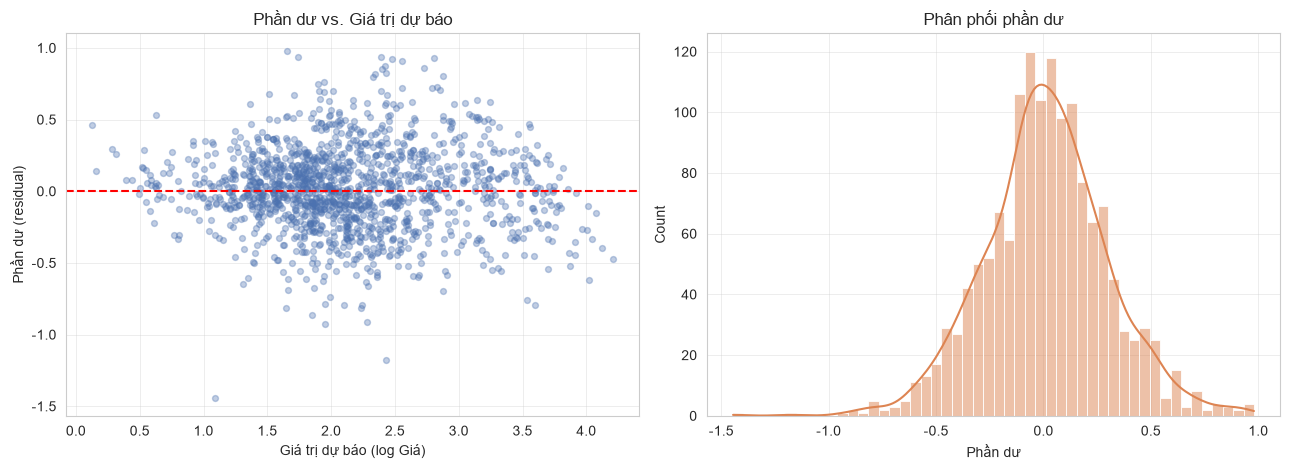

In [420]:
residuals = y_test.values - y_pred_log   # phần dư trên thang log (đúng thang OLS giả định)

fig, axes = plt.subplots(1, 2, figsize=(13,4.8))
axes[0].scatter(y_pred_log, residuals, alpha=0.35, s=18, color='#4C72B0')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Giá trị dự báo (log Giá)')
axes[0].set_ylabel('Phần dư (residual)')
axes[0].set_title('Phần dư vs. Giá trị dự báo')

sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Phân phối phần dư')
axes[1].set_xlabel('Phần dư')
plt.tight_layout()
plt.show()


> **Kiểm tra giả định hồi quy:**
> - Phần dư phân bố tương đối ngẫu nhiên quanh 0, không có xu hướng hình phễu rõ rệt → giả định **phương sai đồng nhất (homoscedasticity)** được đáp ứng tương đối tốt sau khi log hoá.
> - Phân phối phần dư gần với phân phối chuẩn (dạng hình chuông), phù hợp giả định **phần dư có phân phối chuẩn**.

### 6.3. Biểu đồ Q-Q (kiểm tra tính chuẩn của phần dư)

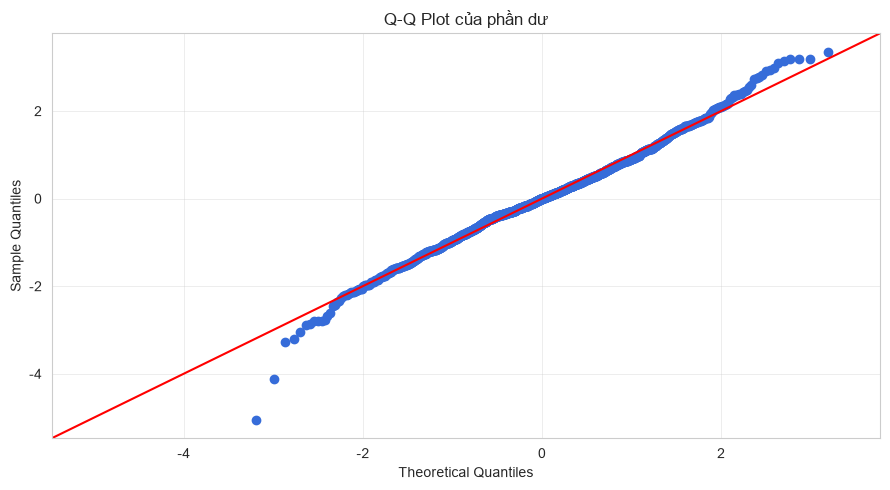

In [421]:
fig = sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot của phần dư')
plt.tight_layout()
plt.show()


### 6.4. Kiểm định Durbin-Watson (tính độc lập của sai số)

In [422]:
dw_stat = durbin_watson(ols_model.resid)
print(f"Chỉ số Durbin-Watson: {dw_stat:.3f}")
print("Giá trị gần 2 => phần dư không có hiện tượng tự tương quan đáng kể.")


Chỉ số Durbin-Watson: 1.968
Giá trị gần 2 => phần dư không có hiện tượng tự tương quan đáng kể.


### 6.5. So sánh sai số theo phân khúc giá

In [423]:
seg = pd.cut(y_true, bins=[0,3,7,15,30,10000],
              labels=['<3 tỷ','3-7 tỷ','7-15 tỷ','15-30 tỷ','>30 tỷ'])
err_by_seg = pd.DataFrame({'seg':seg, 'ape': np.abs((y_true-y_pred)/y_true)*100})
seg_summary = err_by_seg.groupby('seg', observed=True)['ape'].agg(['mean','count']).rename(
    columns={'mean':'MAPE trung bình (%)','count':'Số quan sát'})
seg_summary


,MAPE trung bình (%),Số quan sát
seg,,
<3 tỷ,28.228149,90
3-7 tỷ,21.034748,565
7-15 tỷ,21.524103,466
15-30 tỷ,25.262541,211
>30 tỷ,24.518733,113


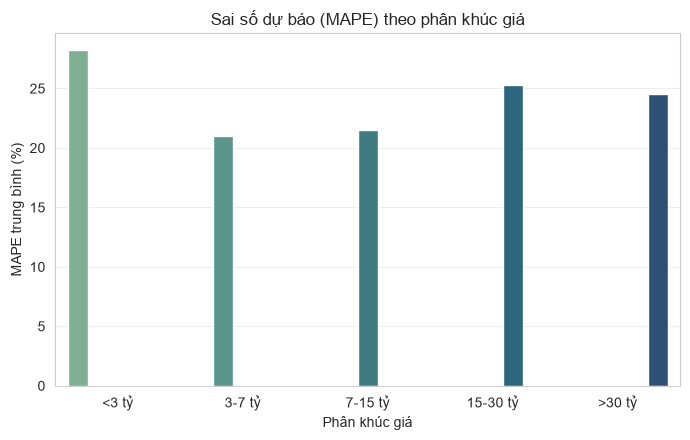

In [424]:
plt.figure(figsize=(7,4.5))
sns.barplot(x=seg_summary.index, y=seg_summary['MAPE trung bình (%)'],
            hue=seg_summary.index, palette='crest', legend=False)
plt.ylabel('MAPE trung bình (%)')
plt.xlabel('Phân khúc giá')
plt.title('Sai số dự báo (MAPE) theo phân khúc giá')
plt.tight_layout()
plt.show()


> **Nhận xét:** Mô hình thường dự báo chính xác hơn ở phân khúc giá phổ biến (nhà/căn hộ tầm trung); sai số phần trăm có xu hướng tăng ở phân khúc giá rất cao — phù hợp với quan sát ở mục 5.1 rằng dữ liệu và mô hình tuyến tính khó nắm bắt hết các yếu tố định giá của bất động sản cao cấp/hiếm.

## 7. Kết luận

**Kết quả chính:**
- Sau tiền xử lý, dữ liệu từ dạng thô hơn 13.500 tin rao còn lại một tập dữ liệu sạch gồm các bất động sản để ở tại Hà Nội, đầy đủ giá bán và diện tích, đã loại bỏ dữ liệu ngoại lai/dữ liệu lỗi.
- Diện tích (`log_Area`) là yếu tố ảnh hưởng mạnh và nhất quán nhất đến giá nhà.
- Vị trí (quận/huyện) tạo ra chênh lệch giá rất lớn, phản ánh đúng thực tế thị trường (giá tại các quận trung tâm cao hơn nhiều so với vùng ven).
- Loại hình bất động sản, tình trạng pháp lý, nội thất cũng có ảnh hưởng có ý nghĩa thống kê đến giá bán.
- Mô hình hồi quy tuyến tính đa biến (trên thang log) đạt R² ở mức khá tốt, đủ để sử dụng như một công cụ tham khảo, ước lượng nhanh giá trị bất động sản.

**Hạn chế:**
- Dữ liệu là tin rao (giá chào bán), có thể khác giá giao dịch thực tế.
- Thiếu các biến định tính quan trọng: vị trí cụ thể (mặt đường lớn/ngõ nhỏ), hướng ban công, tầm nhìn, chất lượng xây dựng, tiện ích xung quanh...
- Mô hình tuyến tính có thể chưa nắm bắt tốt các quan hệ phi tuyến hoặc tương tác phức tạp giữa các biến — có thể cải thiện bằng các mô hình phi tuyến (Random Forest, Gradient Boosting) trong nghiên cứu tiếp theo.

**Hướng phát triển:**
- Thu thập thêm biến vị trí chi tiết hơn (toạ độ, khoảng cách tới trung tâm, trường học, đường lớn...).
- So sánh với các mô hình máy học phi tuyến tính để đối chiếu hiệu năng.
- Cập nhật dữ liệu theo thời gian để xây dựng mô hình dự báo xu hướng giá.
